# 07 — Result analysis
Đọc `results/summary/results_summary.csv` và `results/predictions/all_predictions.csv` (tạo bởi `src/evaluate.py`). Mọi so sánh trong cùng fold/seed dùng cùng classifier, cùng split. Kết quả chính: seed 0, 6 fold; multi-seed chỉ tại d=128.

In [1]:
import sys, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plotstyle; plotstyle.apply()
from plotstyle import SERIES, TEXT2, METHOD_COLORS
FIG = ROOT / 'results' / 'figures'; SUM = ROOT / 'results' / 'summary'; PRED = ROOT / 'results' / 'predictions'
LOGS = ROOT / 'results' / 'logs'
pd.set_option('display.float_format', '{:.4f}'.format)
s = pd.read_csv(SUM / 'results_summary.csv'); s0 = s[s.seed == 0]
ORDER = ['Task-AE', 'AE-MSE', 'DCT', 'Low-Mel']
A0 = s0[s0.method == 'Original'].Accuracy
print(f'A0 (Original FP32, seed 0): mean {A0.mean():.4f} ± {A0.std():.4f} over 6 folds')
pd.read_csv(SUM / 'results_summary_mean.csv')

A0 (Original FP32, seed 0): mean 0.4233 ± 0.1367 over 6 folds


,scope,method,d,bytes,Accuracy_mean,Accuracy_std,Macro_F1_mean,Macro_F1_std,Delta_A_pp_mean,Delta_A_pp_std,R_acc_mean,R_acc_std,MSE_mean,MSE_std,PRD_spec_mean,PRD_spec_std,n_runs,CR_INT8,CR_FP32
0,"seed 0, 6 folds",AE-MSE,64,68,0.3447,0.1218,0.2925,0.1189,-7.8667,4.5513,80.7399,9.9692,0.1064,0.0293,29.5218,5.2722,6,30.1765,120.5294
1,"seed 0, 6 folds",AE-MSE,128,132,0.4040,0.1344,0.3589,0.1383,-1.9333,3.3315,95.0660,8.4823,0.0679,0.0233,23.8243,5.0653,6,15.5455,62.0909
2,"seed 0, 6 folds",AE-MSE,256,260,0.4153,0.1427,0.3683,0.1445,-0.8000,1.9391,97.3038,5.5254,0.0469,0.0173,20.0525,4.5326,6,7.8923,31.5231
3,"seed 0, 6 folds",DCT,64,68,0.3183,0.1082,0.2576,0.1075,-10.5000,4.6230,74.7773,8.1254,0.1318,0.0494,32.9253,7.1177,6,30.1765,120.5294
4,"seed 0, 6 folds",DCT,128,132,0.3913,0.1405,0.3474,0.1416,-3.2000,3.4246,91.2972,9.1094,0.0829,0.0296,26.5764,5.7747,6,15.5455,62.0909
5,"seed 0, 6 folds",DCT,256,260,0.4160,0.1391,0.3705,0.1413,-0.7333,2.6643,97.8376,6.5976,0.0539,0.0215,21.9071,5.2099,6,7.8923,31.5231
6,"seed 0, 6 folds",INT8,2048,2052,0.4223,0.1376,0.3718,0.1497,-0.1000,0.1673,99.6613,0.4615,0.0003,0.0000,1.7652,0.0047,6,1.0000,3.9942
7,"seed 0, 6 folds",Low-Mel,64,68,0.1000,0.0000,0.0182,0.0000,-32.3333,13.6655,26.3606,10.3008,0.9917,0.1316,94.6931,1.6918,6,30.1765,120.5294
8,"seed 0, 6 folds",Low-Mel,128,132,0.1017,0.0041,0.0201,0.0046,-32.1667,13.6502,26.7411,10.1858,0.9599,0.1374,91.2874,2.2103,6,15.5455,62.0909
9,"seed 0, 6 folds",Low-Mel,256,260,0.1063,0.0155,0.0228,0.0113,-31.7000,13.6720,27.8065,10.3151,0.8962,0.1474,83.8391,3.3780,6,7.8923,31.5231


## Figure 1 — Accuracy vs bytes (đồ thị chính)
Điểm = trung bình 6 fold, thanh = ±1 std; đường ngang = Original FP32 (8196 B) và Direct INT8 (2052 B).

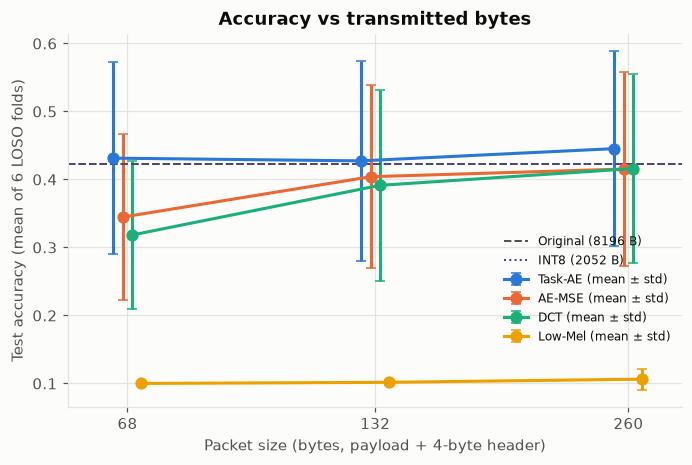

In [2]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for k, m in enumerate(ORDER):
    g = s0[s0.method == m].groupby('bytes').Accuracy.agg(['mean', 'std'])
    xs = g.index * (1 + 0.025 * (k - 1.5))  # small horizontal offset so error bars do not overlap
    ax.errorbar(xs, g['mean'], yerr=g['std'], marker='o', capsize=3, color=METHOD_COLORS[m], label=f'{m} (mean ± std)')
for m, ls in [('Original', '--'), ('INT8', ':')]:
    v = s0[s0.method == m].Accuracy.mean()
    ax.axhline(v, color=METHOD_COLORS[m], ls=ls, lw=1.3, label=f'{m} ({int(s0[s0.method == m].bytes.iloc[0])} B)')
ax.set_xscale('log'); ax.set_xticks([68, 132, 260], ['68', '132', '260']); ax.minorticks_off(); ax.set_xlim(58, 300)
ax.set(xlabel='Packet size (bytes, payload + 4-byte header)', ylabel='Test accuracy (mean of 6 LOSO folds)',
       title='Accuracy vs transmitted bytes')
ax.legend(loc='lower right', bbox_to_anchor=(1, 0.14), fontsize=8)
fig.savefig(FIG / 'accuracy_vs_bytes.png'); plt.show()

## Figure 2 — Task-AE − AE-MSE theo test speaker

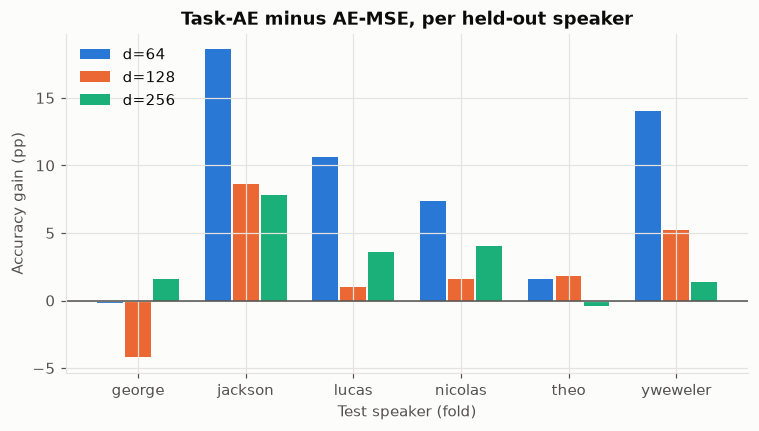

d,64,128,256
test_speaker,,,
george,-0.2000,-4.2000,1.6000
jackson,18.6000,8.6000,7.8000
lucas,10.6000,1.0000,3.6000
nicolas,7.4000,1.6000,4.0000
theo,1.6000,1.8000,-0.4000
yweweler,14.0000,5.2000,1.4000


mean gain (pp) per d:
d
64    8.6700
128   2.3300
256   3.0000
folds with positive gain per d:
d
64     5
128    5
256    5


In [3]:
p = s0[s0.method.isin(['Task-AE', 'AE-MSE'])].pivot_table(index=['test_speaker', 'd'], columns='method', values='Accuracy')
p['gain_pp'] = 100 * (p['Task-AE'] - p['AE-MSE']); gain = p.gain_pp.unstack('d')
fig, ax = plt.subplots(figsize=(8, 4)); w = 0.26
for i, d in enumerate(gain.columns):
    ax.bar(np.arange(len(gain)) + (i - 1) * w, gain[d], width=w - 0.02, color=SERIES[i], label=f'd={d}')
ax.axhline(0, color=TEXT2, lw=1); ax.set_xticks(range(len(gain)), gain.index)
ax.set(xlabel='Test speaker (fold)', ylabel='Accuracy gain (pp)', title='Task-AE minus AE-MSE, per held-out speaker')
ax.legend(); fig.savefig(FIG / 'task_gain_by_speaker.png'); plt.show()
display(gain); print('mean gain (pp) per d:'); print(gain.mean().round(2).to_string())
print('folds with positive gain per d:'); print((gain > 0).sum().to_string())

## Figure 3 — MSE vs Accuracy
Mỗi điểm = một (method, d, fold). Dùng để kiểm tra: MSE thấp hơn có đồng nghĩa accuracy cao hơn không.

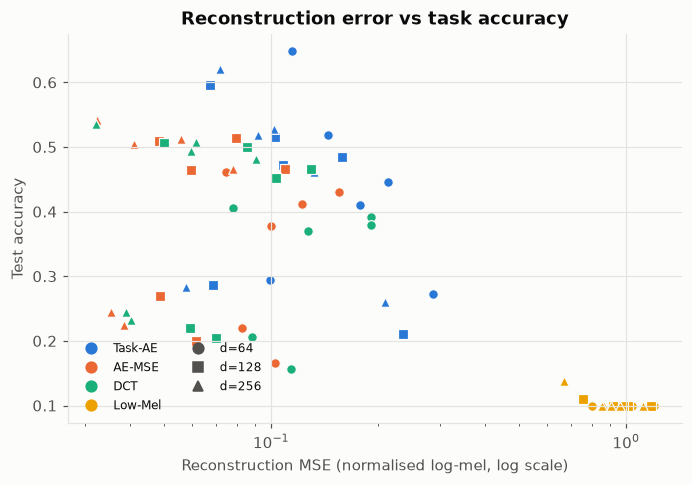

(fold,d) cases where Task-AE has HIGHER MSE but HIGHER accuracy than AE-MSE: 15 / 18


In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
markers = {64: 'o', 128: 's', 256: '^'}
for m in ORDER:
    for d, mk in markers.items():
        g = s0[(s0.method == m) & (s0.d == d)]
        ax.scatter(g.MSE, g.Accuracy, color=METHOD_COLORS[m], marker=mk, s=40, edgecolor='#fcfcfb', lw=0.8)
ax.set_xscale('log')
h1 = [plt.Line2D([], [], color=METHOD_COLORS[m], marker='o', ls='') for m in ORDER]
h2 = [plt.Line2D([], [], color=TEXT2, marker=mk, ls='') for mk in markers.values()]
ax.legend(h1 + h2, ORDER + [f'd={d}' for d in markers], fontsize=8, ncol=2, loc='lower left')
ax.set(xlabel='Reconstruction MSE (normalised log-mel, log scale)', ylabel='Test accuracy', title='Reconstruction error vs task accuracy')
fig.savefig(FIG / 'mse_vs_accuracy.png'); plt.show()
pair = s0[s0.method.isin(['Task-AE', 'AE-MSE'])].pivot_table(index=['fold', 'd'], columns='method', values=['MSE', 'Accuracy'])
both = ((pair['MSE']['Task-AE'] > pair['MSE']['AE-MSE']) & (pair['Accuracy']['Task-AE'] > pair['Accuracy']['AE-MSE']))
print(f'(fold,d) cases where Task-AE has HIGHER MSE but HIGHER accuracy than AE-MSE: {both.sum()} / {len(both)}')

## Figure 4 — Compression ratio vs accuracy retention

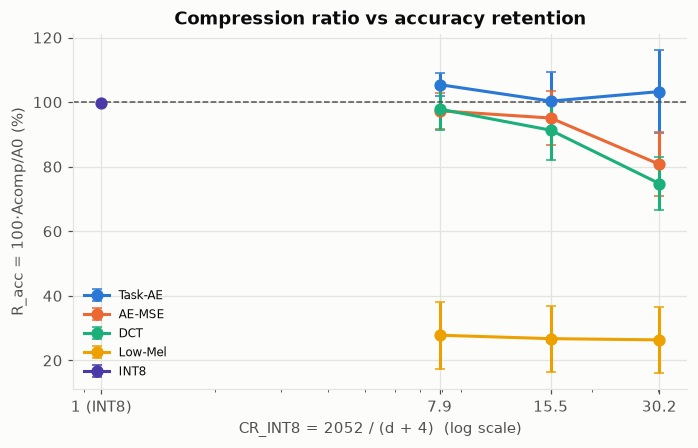

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for m in ORDER + ['INT8']:
    g = s0[s0.method == m].groupby('CR_INT8').R_acc.agg(['mean', 'std'])
    ax.errorbar(g.index, g['mean'], yerr=g['std'], marker='o', capsize=3, color=METHOD_COLORS[m], label=m)
ax.axhline(100, color=TEXT2, ls='--', lw=1)
ax.set_xscale('log'); ax.set_xticks([1, 2052/260, 2052/132, 2052/68], ['1 (INT8)', '7.9', '15.5', '30.2'])
ax.set(xlabel='CR_INT8 = 2052 / (d + 4)  (log scale)', ylabel='R_acc = 100·Acomp/A0 (%)', title='Compression ratio vs accuracy retention')
ax.legend(fontsize=8); fig.savefig(FIG / 'compression_vs_retention.png'); plt.show()

## Figure 5 — Accuracy theo test speaker (d=128)

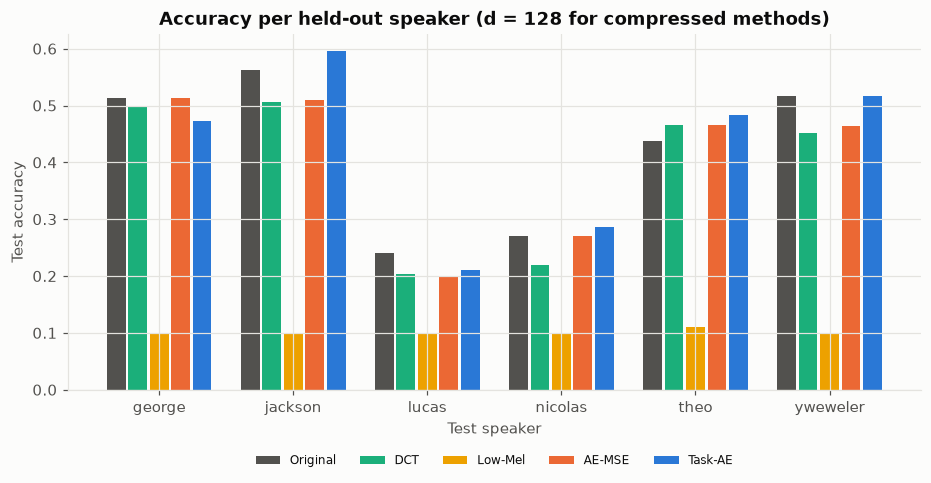

method,Original,DCT,Low-Mel,AE-MSE,Task-AE
test_speaker,,,,,
george,0.5140,0.5000,0.1000,0.5140,0.4720
jackson,0.5620,0.5060,0.1000,0.5100,0.5960
lucas,0.2400,0.2040,0.1000,0.2000,0.2100
nicolas,0.2700,0.2200,0.1000,0.2700,0.2860
theo,0.4380,0.4660,0.1100,0.4660,0.4840
yweweler,0.5160,0.4520,0.1000,0.4640,0.5160


In [6]:
meths = ['Original', 'DCT', 'Low-Mel', 'AE-MSE', 'Task-AE']
sub = s0[(s0.method == 'Original') | (s0.d == 128)]
p5 = sub.pivot_table(index='test_speaker', columns='method', values='Accuracy')[meths]
fig, ax = plt.subplots(figsize=(10, 4.2)); w = 0.16
for i, m in enumerate(meths):
    ax.bar(np.arange(len(p5)) + (i - 2) * w, p5[m], width=w - 0.02, color=METHOD_COLORS[m], label=m)
ax.set_xticks(range(len(p5)), p5.index)
ax.set(xlabel='Test speaker', ylabel='Test accuracy', title='Accuracy per held-out speaker (d = 128 for compressed methods)')
ax.legend(ncol=5, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15))
fig.savefig(FIG / 'accuracy_by_speaker.png'); plt.show(); p5

## Figure 6 — Confusion matrices (seed 0, gộp 6 fold)

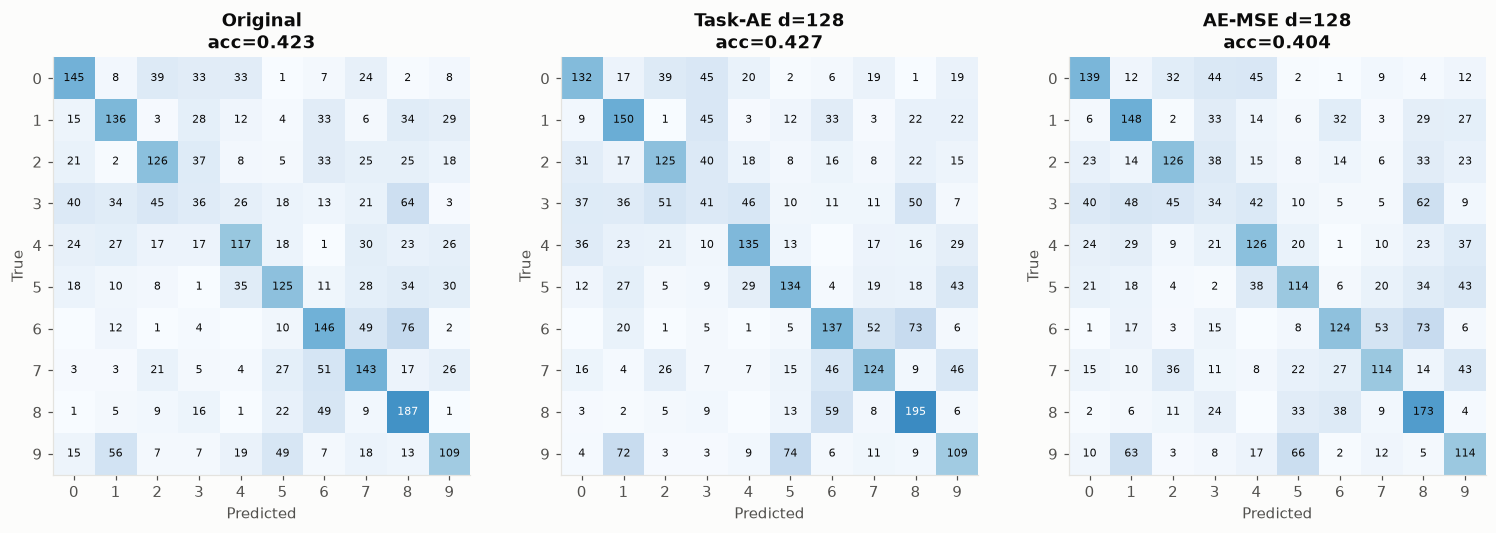

In [7]:
def confmat(df, title, ax):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(df.label, df.prediction, labels=range(10))
    cmn = cm / cm.sum(1, keepdims=True)
    ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1); ax.grid(False)
    for i in range(10):
        for j in range(10):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                        color='white' if cmn[i, j] > 0.6 else '#0b0b0b')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set(xlabel='Predicted', ylabel='True', title=f'{title}\nacc={df.correct.mean():.3f}')
ap = pd.read_csv(PRED / 'all_predictions.csv'); ap0 = ap[ap.seed == 0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (m, d) in zip(axes, [('Original', 2048), ('Task-AE', 128), ('AE-MSE', 128)]):
    confmat(ap0[(ap0.method == m) & (ap0.d == d)], f'{m}' + ('' if m == 'Original' else f' d={d}'), ax)
fig.tight_layout(); fig.savefig(FIG / 'confusion_matrices.png'); plt.show()

## Multi-seed tại d=128 (seeds 0, 1, 2)

In [8]:
ms = s[(s.d == 128) | (s.method == 'Original')]
t = ms.groupby(['method', 'seed']).Accuracy.mean().unstack('seed'); t['mean'] = t.mean(1); t['std'] = t.iloc[:, :3].std(1)
display(t)
pp = ms[ms.method.isin(['Task-AE', 'AE-MSE'])].pivot_table(index=['seed', 'fold'], columns='method', values='Accuracy')
d_pp = 100 * (pp['Task-AE'] - pp['AE-MSE'])
print(f'Descriptive: Task-AE − AE-MSE at d=128 over {len(d_pp)} (seed, speaker) pairs: mean {d_pp.mean():.2f} pp, '
      f'positive in {(d_pp > 0).sum()}/{len(d_pp)} (pairs are NOT independent: 3 seeds share each speaker)')
# Inference unit = held-out speaker: average the 3 seeds per speaker -> 6 paired observations
spk = ms[ms.method.isin(['Task-AE', 'AE-MSE'])].groupby(['test_speaker', 'method']).Accuracy.mean().unstack()
spk['gain_pp'] = 100 * (spk['Task-AE'] - spk['AE-MSE']); display(spk)
from scipy.stats import wilcoxon, ttest_rel
print(f"Speaker level (n=6): mean gain {spk.gain_pp.mean():.2f} pp, std {spk.gain_pp.std():.2f}, positive {(spk.gain_pp > 0).sum()}/6")
print('Wilcoxon signed-rank, exact, two-sided (n=6; smallest attainable p = 0.031):', wilcoxon(spk['Task-AE'], spk['AE-MSE']))
print('Paired t-test (n=6):', ttest_rel(spk['Task-AE'], spk['AE-MSE']))
spk.to_csv(SUM / 'task_vs_mse_d128_speaker_level.csv')

seed,0,1,2,mean,std
method,,,,,
AE-MSE,0.4040,0.4197,0.4413,0.4217,0.0187
DCT,0.3913,0.4400,0.4363,0.4226,0.0271
Low-Mel,0.1017,0.1000,0.1000,0.1006,0.0010
Original,0.4233,0.4450,0.4573,0.4419,0.0172
Task-AE,0.4273,0.4503,0.4633,0.4470,0.0182


Descriptive: Task-AE − AE-MSE at d=128 over 18 (seed, speaker) pairs: mean 2.53 pp, positive in 16/18 (pairs are NOT independent: 3 seeds share each speaker)


method,AE-MSE,Task-AE,gain_pp
test_speaker,,,
george,0.5087,0.5020,-0.6667
jackson,0.5480,0.6073,5.9333
lucas,0.2520,0.2747,2.2667
nicolas,0.2947,0.3127,1.8000
theo,0.4660,0.4693,0.3333
yweweler,0.4607,0.5160,5.5333


Speaker level (n=6): mean gain 2.53 pp, std 2.69, positive 5/6
Wilcoxon signed-rank, exact, two-sided (n=6; smallest attainable p = 0.031): WilcoxonResult(statistic=np.float64(2.0), pvalue=np.float64(0.09375))
Paired t-test (n=6): TtestResult(statistic=np.float64(2.30465337310873), pvalue=np.float64(0.06936841366428145), df=np.int64(5))


## Ablation λ (chỉ Validation, d=128, seed 0)

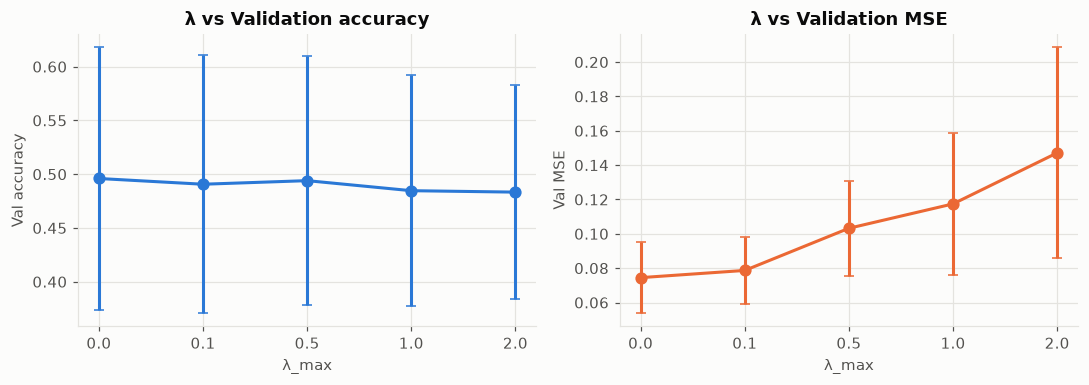

Val_Accuracy        Val_MSE       
                   mean    std    mean    std
lambda_max                                   
0.0000           0.4960 0.1219  0.0745 0.0206
0.1000           0.4907 0.1198  0.0787 0.0195
0.5000           0.4940 0.1159  0.1032 0.0276
1.0000           0.4847 0.1073  0.1174 0.0415
2.0000           0.4833 0.0994  0.1471 0.0614

In [9]:
ab = pd.read_csv(SUM / 'lambda_ablation_val.csv')
g = ab.groupby('lambda_max')[['Val_Accuracy', 'Val_MSE']].agg(['mean', 'std'])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].errorbar(g.index.astype(str), g['Val_Accuracy']['mean'], yerr=g['Val_Accuracy']['std'], marker='o', capsize=3, color=SERIES[0])
axes[0].set(xlabel='λ_max', ylabel='Val accuracy', title='λ vs Validation accuracy')
axes[1].errorbar(g.index.astype(str), g['Val_MSE']['mean'], yerr=g['Val_MSE']['std'], marker='o', capsize=3, color=SERIES[1])
axes[1].set(xlabel='λ_max', ylabel='Val MSE', title='λ vs Validation MSE')
fig.tight_layout(); fig.savefig(FIG / 'lambda_ablation.png'); plt.show(); g

## Bảng tổng hợp cho báo cáo (seed 0, mean ± std qua 6 fold)

In [10]:
cols = ['Accuracy', 'Macro_F1', 'Delta_A_pp', 'R_acc', 'MSE', 'PRD_spec']
agg = s0.groupby(['method', 'd', 'bytes', 'CR_INT8', 'CR_FP32'])[cols].agg(['mean', 'std'])
report = pd.DataFrame({c: agg[c]['mean'].map('{:.3f}'.format) + ' ± ' + agg[c]['std'].map('{:.3f}'.format) for c in cols})
report = report.reset_index().sort_values(['bytes', 'method'], ascending=[False, True])
report.to_csv(SUM / 'report_table_seed0.csv', index=False); report

,method,d,bytes,CR_INT8,CR_FP32,Accuracy,Macro_F1,Delta_A_pp,R_acc,MSE,PRD_spec
10,Original,2048,8196,0.2504,1.0000,0.423 ± 0.137,0.373 ± 0.148,0.000 ± 0.000,100.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
6,INT8,2048,2052,1.0000,3.9942,0.422 ± 0.138,0.372 ± 0.150,-0.100 ± 0.167,99.661 ± 0.462,0.000 ± 0.000,1.765 ± 0.005
2,AE-MSE,256,260,7.8923,31.5231,0.415 ± 0.143,0.368 ± 0.145,-0.800 ± 1.939,97.304 ± 5.525,0.047 ± 0.017,20.053 ± 4.533
5,DCT,256,260,7.8923,31.5231,0.416 ± 0.139,0.370 ± 0.141,-0.733 ± 2.664,97.838 ± 6.598,0.054 ± 0.021,21.907 ± 5.210
9,Low-Mel,256,260,7.8923,31.5231,0.106 ± 0.016,0.023 ± 0.011,-31.700 ± 13.672,27.807 ± 10.315,0.896 ± 0.147,83.839 ± 3.378
13,Task-AE,256,260,7.8923,31.5231,0.445 ± 0.144,0.406 ± 0.154,2.200 ± 1.914,105.405 ± 3.610,0.111 ± 0.055,30.689 ± 7.712
1,AE-MSE,128,132,15.5455,62.0909,0.404 ± 0.134,0.359 ± 0.138,-1.933 ± 3.331,95.066 ± 8.482,0.068 ± 0.023,23.824 ± 5.065
4,DCT,128,132,15.5455,62.0909,0.391 ± 0.140,0.347 ± 0.142,-3.200 ± 3.425,91.297 ± 9.109,0.083 ± 0.030,26.576 ± 5.775
8,Low-Mel,128,132,15.5455,62.0909,0.102 ± 0.004,0.020 ± 0.005,-32.167 ± 13.650,26.741 ± 10.186,0.960 ± 0.137,91.287 ± 2.210
12,Task-AE,128,132,15.5455,62.0909,0.427 ± 0.147,0.388 ± 0.154,0.400 ± 3.492,100.301 ± 8.994,0.124 ± 0.064,31.866 ± 8.770
